In [1]:
import numpy as np
import matplotlib.pyplot as plt
from CheTTNS_A_B import *
from pytreenet.core import Node
from pytreenet.ttns import TreeTensorNetworkState
from pytreenet.ttno import TreeTensorNetworkOperator
from pytreenet.operators import Hamiltonian, TensorProduct
from pytreenet.random import crandn
from pytreenet.core import Node
from pytreenet.ttns import TreeTensorNetworkState
from pytreenet.ttno import TreeTensorNetworkOperator
from pytreenet.operators.models.two_site_model import XYModel
from pytreenet.operators.common_operators import *
from pytreenet.util import SVDParameters

In [2]:
def rescale(initial_state: TreeTensorNetworkState, Hamiltonian: TreeTensorNetworkOperator, W, W_prime=0.9875):

    E_min, psi_min = dmrg_min(initial_state=initial_state, hamiltonian=Hamiltonian)
    
    a =  W / (2 * W_prime)

    H_scaled = copy.deepcopy(Hamiltonian)
    H_scaled.tensors[H_scaled.root_id] *= (1.0 / a)

    shift = (E_min / a) + W_prime

    return H_scaled, a, shift, E_min, psi_min

In [3]:
def cheb_ttns_Direct(v_ket: TreeTensorNetworkState,
              H_scaled: TreeTensorNetworkOperator,
              N: int,
              svd_params: SVDParameters,
              num_sweeps= 2,
              dtype=np.float64,
              ):
    phi_initial = copy.deepcopy(v_ket)
    # phi_initial.canonical_form(phi_initial.root_id)
    psi_list = [phi_initial]

    if N > 1:
        psi1 = apply_ttno_to_ttns(ttns= psi_list[0], ttno=H_scaled, method=ApplicationMethod.DIRECT)
        # psi1.canonical_form(psi1.root_id)
        psi_list.append(psi1)

    for n in range(1, N-1):
        Hprime = apply_ttno_to_ttns(ttns= psi_list[n], ttno=H_scaled, method=ApplicationMethod.DIRECT)
        psi_np1 = linear_combination([Hprime, psi_list[n-1]], [2.0, -1.0],
                                     svd_params.max_bond_dim, num_sweeps, dtype=dtype)
        # psi_np1.canonical_form(psi_np1.root_id)
        psi_list.append(psi_np1)


    return psi_list

### XY Model 1D，12-site

In [4]:
ttns = TreeTensorNetworkState()

N = 24          # total number of sites
D = 40          # bond dimension
d = 2           # physical dimension

# root site
root_node = Node(identifier="0")
root_tensor = crandn((D, d))   # one virtual leg + one physical leg
ttns.add_root(root_node, root_tensor)

parent = "0"

# build a 1D open chain: 0 - 1 - 2 - ... - 11
for i in range(1, N):
    node_id = str(i)
    node = Node(identifier=node_id)

    if i == N - 1:
        # last site: one virtual leg + one physical leg
        tensor = crandn((D, d))
    else:
        # internal site: two virtual legs + one physical leg
        tensor = crandn((D, D, d))

    # child leg = 0
    # parent leg = 0 for root, otherwise use the outgoing chain leg = 1
    if parent == "0":
        ttns.add_child_to_parent(node, tensor, 0, parent, 0)
    else:
        ttns.add_child_to_parent(node, tensor, 0, parent, 1)

    parent = node_id

ttns.normalize()

model = XYModel(interaction_range=1, x_factor=1.0, y_factor=1.0, ext_z=0.0)
XY_ham = model.generate_hamiltonian(ttns)
ttno = TreeTensorNetworkOperator.from_hamiltonian(XY_ham, ttns)

site_ids = list(ttns.nodes.keys())
print("Number of sites:", len(site_ids))
print("Site ids:", site_ids)

Number of sites: 24
Site ids: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23']


### Construct operator A and B

In [5]:
S_ham = create_sz_operator(site_ids = site_ids)
S_copy = copy.deepcopy(S_ham)
S_ttno = TreeTensorNetworkOperator.from_hamiltonian(S_copy, ttns)

### Compute eigenvalue

In [6]:
L = len(site_ids)
m = np.arange(1, L + 1)
omega = 2 * np.abs(np.cos(m * np.pi / (L + 1)))

omega_unique = np.unique(np.round(omega, 12))

print(omega_unique)

[0.12558104 0.37476263 0.61803399 0.85155858 1.07165359 1.27484798
 1.45793725 1.61803399 1.75261336 1.85955297 1.93716632 1.9842294 ]


### Rescale Hamiltonian

In [7]:
H_scaled, a, E_min, psi_min = rescale_TTNO(ttns, ttno)
print("E_min:", E_min)
psi_min.normalise()
E_min_rescale,  _ = dmrg_min(ttns, H_scaled)
print("E_min_rescale:", E_min_rescale)

E_min: -7.462985552646657
E_min_rescale: -0.9874999999998386


### Compute bra and ket ttns

In [8]:
svd_params = SVDParameters(max_bond_dim=32, rel_tol=0.0, total_tol=0.0, sum_trunc=False)

psi_ket = copy.deepcopy(psi_min)
psi_ket = apply_ttno_to_ttns(ttns= psi_ket, ttno= S_ttno, method=ApplicationMethod.DENSITY_MATRIX, svd_params=svd_params)

psi_bra = copy.deepcopy(psi_min)
psi_bra = apply_ttno_to_ttns(ttns= psi_bra, ttno= S_ttno, method=ApplicationMethod.DENSITY_MATRIX, svd_params=svd_params)

### Computing Chebyshev TTNS

In [9]:
ttns_list = cheb_ttns_Direct(psi_ket, H_scaled, N= 300, svd_params=svd_params)
print(len(ttns_list))

mu = chebyshev_moments_ttns(psi_bra, ttns_list)
print(len(mu))

/Users/link/Desktop/A_Python_code/Test_pytreenet/pytreenet/dmrg/variational_fitting.py:298: ComplexWarning: Casting complex values to real discards the imaginary part
  hamiltonian_eff_site = hamiltonian_eff_site.astype(self.dtype)
/Users/link/Desktop/A_Python_code/Test_pytreenet/pytreenet/dmrg/variational_fitting.py:252: ComplexWarning: Casting complex values to real discards the imaginary part
  return loc_contr().astype(self.dtype)
/Users/link/miniforge3/lib/python3.12/site-packages/scipy/sparse/linalg/_isolve/utils.py:115: ComplexWarning: Casting complex values to real discards the imaginary part
  x = array(x0, dtype=xtype)


300
300


In [10]:
C, ovp = cholesky_ttns(ttns_list)

I_eff = C.conj().T @ ovp @ C
print("||I_eff_mat - I||_F =", np.linalg.norm(I_eff - np.eye(I_eff.shape[0]), 'fro'))

||I_eff_mat - I||_F = 3.5210998795340786e-08


### Heff

In [11]:
Heff = heff_ttns(ttns_list, C, H_scaled)
print(Heff.shape)

(300, 300)


### Computing bra and ket vector

In [12]:
v_ket = psi_eff_ttns(ttns_list, C, psi_ket)

print(len(v_ket))

v_bra = psi_eff_ttns(ttns_list, C, psi_bra)

print(len(v_bra))

300
300


### Effective chebyshev vectors

In [13]:
coChe_vec_list = cheb_vector(Heff, N= 300, v_ket=v_ket)
print(len(coChe_vec_list))

300


### Effective chebyshev moments

In [14]:
mu_eff = chebyshev_moments_vector(v_bra, coChe_vec_list)
print(len(mu_eff))

300


### Chebyshev moments

In [15]:
# mu = chebyshev_moments_ttns(psi_bra, ttns_list)
# print(len(mu))

# Comparing

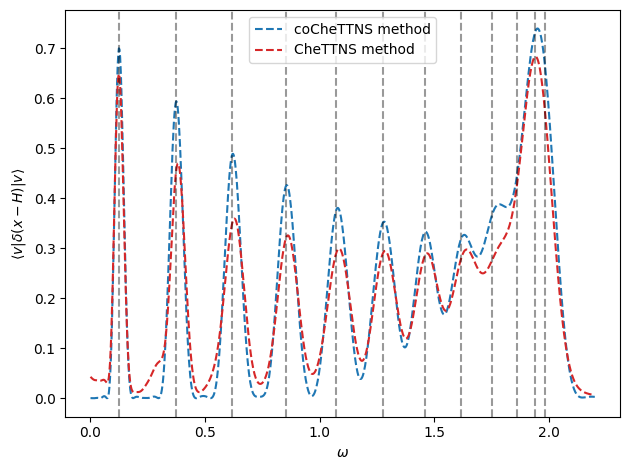

In [16]:
E_max = 2.2
W_prime= 0.9875
x_max = E_max/a - W_prime
x_grid = np.linspace(-0.9875, min(0.999, x_max), 800) 
E_grid = a * (x_grid + W_prime)


vals_ttns = []

for x in x_grid:
    A = reconstruct_delta_spectrum(x=x, mu=mu, a=a)
    vals_ttns.append(A)

vals_ttns = np.array(vals_ttns)


vals_ttns_eff = []

for x in x_grid:
    A = reconstruct_delta_spectrum(x=x, mu=mu_eff, a=a)
    vals_ttns_eff.append(A)

vals_ttns_eff = np.array(vals_ttns_eff)


plt.figure()


plt.plot(
    E_grid,
    vals_ttns_eff,
    color="tab:blue",
    linestyle="--",
    label="coCheTTNS method"
)


plt.plot(
    E_grid,
    vals_ttns,
    color="tab:red",
    linestyle="--",
    label="CheTTNS method"
)


for w in omega_unique:
    plt.axvline(w, color="k", linestyle="--", alpha=0.4)

plt.xlabel(r"$\omega$")
plt.ylabel(r"$\langle v|\delta(x-H)|v\rangle$")
plt.legend()
plt.tight_layout()
plt.show()